SOM

Importing the libraries

In [88]:
import numpy as np

In [89]:
import matplotlib.pyplot as plt

In [90]:
import pandas as pd

Importing the dataset

In [91]:
dataset = pd.read_csv('/content/Credit_Card_Applications.csv')

In [92]:
X = dataset.iloc[:, :-1].values

In [93]:
Y = dataset.iloc[:, -1].values

Feature Scaling

In [94]:
from sklearn.preprocessing import MinMaxScaler

In [95]:
sc = MinMaxScaler(feature_range = (0,1))

In [96]:
X = sc.fit_transform(X)

Training the Som

In [97]:
from minisom import MiniSom

In [98]:
som = MiniSom(x = 10, y = 10, input_len = 15, sigma = 1.0, learning_rate = 0.5)

In [99]:
som.random_weights_init(X)

In [100]:
som.train_random(X, num_iteration = 100)

Visulizing the results

In [101]:
from pylab import bone, pcolor, colorbar, plot, show

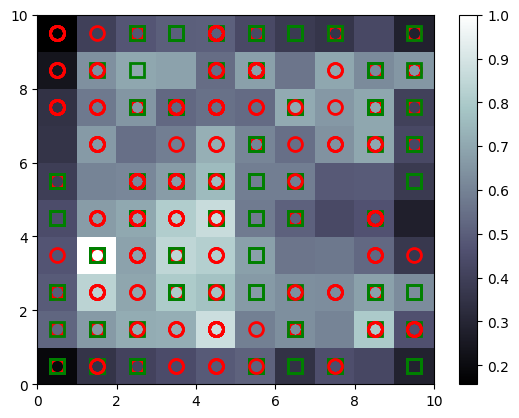

In [107]:
bone()
mappable = pcolor(som.distance_map().T)
colorbar(mappable)
markers = ['o', 's']
colors = ['r','g']
for i, x in enumerate(X):
    w = som.winner(x)
    plot(w[0] + 0.5,
         w[1] + 0.5,
         markers[Y[i]],
         markeredgecolor = colors[Y[i]],
         markerfacecolor = 'None',
         markersize = 10,
         markeredgewidth = 2)

show()

Finding the frauds

In [108]:
mappings = som.win_map(X)

In [111]:
frauds = mappings[(3,1)]

In [112]:
frauds = sc.inverse_transform(frauds)